# §3.4 Advanced Analysis 1: Social Network Mining (with BPMN lane derivation)

First of the two §3.4 bonus analyses, also producing the resource-perspective input for the enriched BPMN in §3.3.

Hypothesis H1: bank employees work in fixed teams handling cases end-to-end, so a simulation should model resources as lane-bound pools.

On the filtered log compute: (1) per-resource workload and the resource × activity profile; (2) a lane mapping (Customer / Bank System / Employee Bank) from the Celonis activity -> lane table (Povalyaeva et al. 2017), with per-lane workload share; (3) the handover-of-work network (Mustroph et al. 2023) and pm4py organisational roles as an independent cross-check.

If H1 holds, simulation needs lane-bound pools with fixed sizes; if not, a single shared FIFO pool is more realistic. The conclusion is in §9.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.seeds import set_all_seeds
set_all_seeds()

import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## 1. Load the filtered log

In [2]:
CASE_COL = "case:concept:name"
ACT_COL  = "concept:name"
TS_COL   = "time:timestamp"
RES_COL  = "org:resource"

df = pd.read_pickle("../data/bpic17_filtered.pkl")
print(f"Log: {df[CASE_COL].nunique():,} cases, {len(df):,} events, "
      f"{df[ACT_COL].nunique()} activities, {df[RES_COL].nunique()} distinct resources")
df[RES_COL].value_counts().head(10)

Log: 31,361 cases, 473,139 events, 24 activities, 144 distinct resources


org:resource
User_1      75704
User_3       9239
User_49      9023
User_10      8288
User_29      8174
User_5       7384
User_28      7186
User_123     6874
User_27      6851
User_68      6505
Name: count, dtype: int64

## 2. Resource workload distribution

Pareto chart of how concentrated work is across resources.

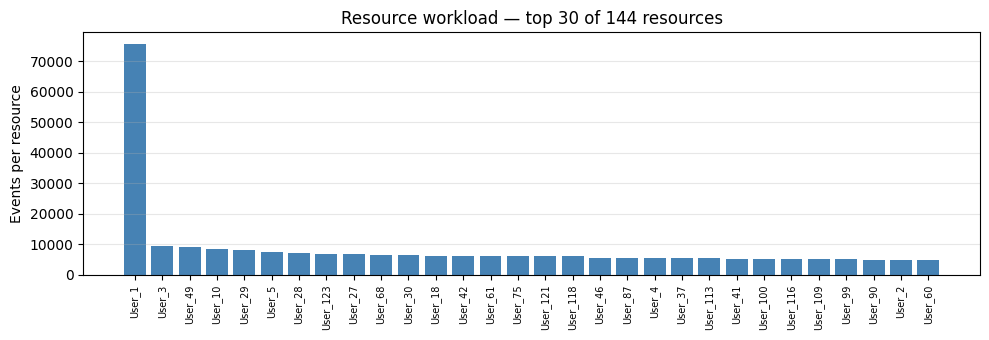

   27 resources cover 50% of all events
   61 resources cover 80% of all events
   81 resources cover 90% of all events
   97 resources cover 95% of all events


In [3]:
res_counts = df[RES_COL].value_counts()
top_n = 30
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(top_n), res_counts.iloc[:top_n].values, color="steelblue")
ax.set_xticks(range(top_n))
ax.set_xticklabels(res_counts.index[:top_n], rotation=90, fontsize=7)
ax.set_ylabel("Events per resource")
ax.set_title(f"Resource workload — top {top_n} of {len(res_counts)} resources")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/resource_workload.pdf")
plt.savefig("../results/figures/resource_workload.png", dpi=150)
plt.show()

# Coverage statistics
cum = res_counts.cumsum() / res_counts.sum()
for cov in [0.5, 0.8, 0.9, 0.95]:
    n = int((cum < cov).sum()) + 1
    print(f"  {n:>3} resources cover {cov:.0%} of all events")


## 3. Resource × Activity matrix

Which activities each resource executes; the basis for the lane mapping below.

Matrix shape: (144, 24)  (resources × activities)


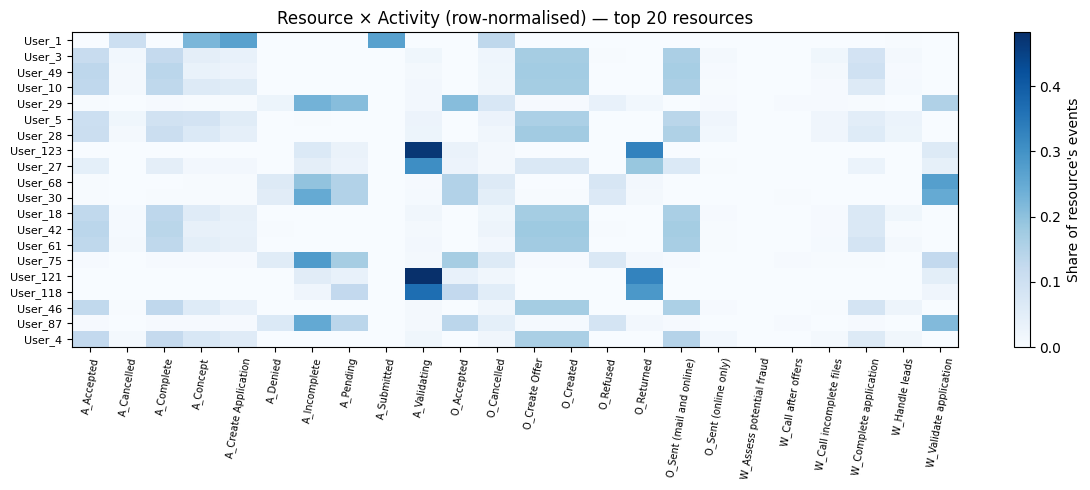

In [4]:
ra_matrix = df.groupby([RES_COL, ACT_COL]).size().unstack(fill_value=0)
print(f"Matrix shape: {ra_matrix.shape}  (resources × activities)")

# Heatmap of the top resources × all activities
top_res = res_counts.head(20).index
heat = ra_matrix.loc[top_res]
heat_norm = heat.div(heat.sum(axis=1), axis=0)  # row-normalised: share of each resource's events per activity

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat_norm.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(heat_norm.shape[1]))
ax.set_xticklabels(heat_norm.columns, rotation=80, fontsize=7)
ax.set_yticks(range(heat_norm.shape[0]))
ax.set_yticklabels(heat_norm.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Share of resource's events")
ax.set_title("Resource × Activity (row-normalised) — top 20 resources")
plt.tight_layout()
plt.savefig("../results/figures/resource_activity_heatmap.pdf")
plt.savefig("../results/figures/resource_activity_heatmap.png", dpi=150)
plt.show()


## 4. Lane derivation

Project each resource onto its dominant lane via the Celonis activity -> lane mapping (Povalyaeva). Resources whose top lane covers ≥80 % of their events are assigned cleanly; the rest land in *Mixed*.

In [ ]:
# Celonis activity -> lane mapping 
LANE_FOR_ACTIVITY = {
    # Customer lane
    "A_Submitted":                "Customer",
    # Bank System lane (automated state changes)
    "A_Concept":                  "Bank System",
    "A_Accepted":                 "Bank System",
    "A_Complete":                 "Bank System",
    "A_Validating":               "Bank System",
    "A_Incomplete":               "Bank System",
    "A_Pending":                  "Bank System",
    "A_Denied":                   "Bank System",
    "A_Cancelled":                "Bank System",
    "O_Returned":                 "Bank System",
    "O_Refused":                  "Bank System",
    "O_Cancelled":                "Bank System",
    "O_Accepted":                 "Bank System",
    "W_Handle leads":             "Bank System",
    # Employee Bank lane (human-operated)
    "A_Create Application":       "Employee Bank",  # mostly employee-assisted. Online cases are in Customer in Celonis 
    "O_Create Offer":             "Employee Bank",
    "O_Created":                  "Employee Bank",
    "O_Sent (mail and online)":   "Employee Bank",
    "O_Sent (online only)":       "Employee Bank",
    "W_Complete application":     "Employee Bank",
    "W_Validate application":     "Employee Bank",
    "W_Call incomplete files":    "Employee Bank",
    "W_Call after offers":        "Employee Bank",
    "W_Assess potential fraud":   "Employee Bank",
    "W_Personal Loan collection": "Employee Bank",
    "W_Shortened completion":     "Employee Bank",
}

# Resource -> lane share
res_lane = df.assign(_lane=df[ACT_COL].map(LANE_FOR_ACTIVITY).fillna("Other"))
lane_share = (
    res_lane.groupby([RES_COL, "_lane"])
            .size()
            .unstack(fill_value=0)
)
lane_share_norm = lane_share.div(lane_share.sum(axis=1), axis=0)

def assign_lane(row, threshold=0.80):
    top_lane = row.idxmax()
    if row[top_lane] >= threshold:
        return top_lane
    return "Mixed"

lane_mapping = pd.DataFrame({
    "events":       res_lane.groupby(RES_COL).size(),
    "lane_top":     lane_share_norm.idxmax(axis=1),
    "lane_share":   lane_share_norm.max(axis=1).round(3),
    "assigned_lane": lane_share_norm.apply(assign_lane, axis=1),
}).sort_values("events", ascending=False)

lane_mapping.to_csv("../results/lane_mapping.csv")
print("Distribution of assigned_lane:")
print(lane_mapping["assigned_lane"].value_counts())
print()
print("Top-20 resources with assigned lane:")
lane_mapping.head(20)


Distribution of assigned_lane:
assigned_lane
Mixed          107
Bank System     37
Name: count, dtype: int64

Top-20 resources with assigned lane:


,events,lane_top,lane_share,assigned_lane
org:resource,,,,
User_1,75704,Bank System,0.463,Mixed
User_3,9239,Employee Bank,0.647,Mixed
User_49,9023,Employee Bank,0.650,Mixed
User_10,8288,Employee Bank,0.629,Mixed
User_29,8174,Bank System,0.820,Bank System
User_5,7384,Employee Bank,0.607,Mixed
User_28,7186,Employee Bank,0.638,Mixed
User_123,6874,Bank System,0.935,Bank System
User_27,6851,Bank System,0.710,Mixed


## 5. Activity-level lane summary

Events per lane. The data-grounded workload split that feeds the BPMN annotation.

In [6]:
lane_events = res_lane.groupby("_lane").size().sort_values(ascending=False)
lane_events_share = (lane_events / lane_events.sum() * 100).round(1)

lane_summary = pd.DataFrame({
    "events":        lane_events,
    "share_percent": lane_events_share,
    "n_resources":   lane_mapping.groupby("assigned_lane").size().reindex(lane_events.index, fill_value=0),
})
lane_summary.to_csv("../results/lane_summary.csv")
lane_summary.to_latex(
    "../results/lane_summary.tex",
    float_format="%.1f",
    caption="Workload share per BPMN lane (Customer / Bank System / Employee Bank) and number of resources cleanly assigned to each lane (\\geq 80 \\% of their events).",
    label="tab:lane_summary",
)
lane_summary


,events,share_percent,n_resources
_lane,,,
Bank System,256097,54.1,37
Employee Bank,196704,41.6,0
Customer,20338,4.3,0


## 6. Social network mining (handover-of-work)

Handover-of-work links resource A to B when B continues a case after A in the same trace; edge weight ≈ collaboration frequency. Computed on the filtered log, visualised for the most active resources.

Handover network: 9390 edges, directed=True
Plot subgraph: 30 nodes, 807 edges


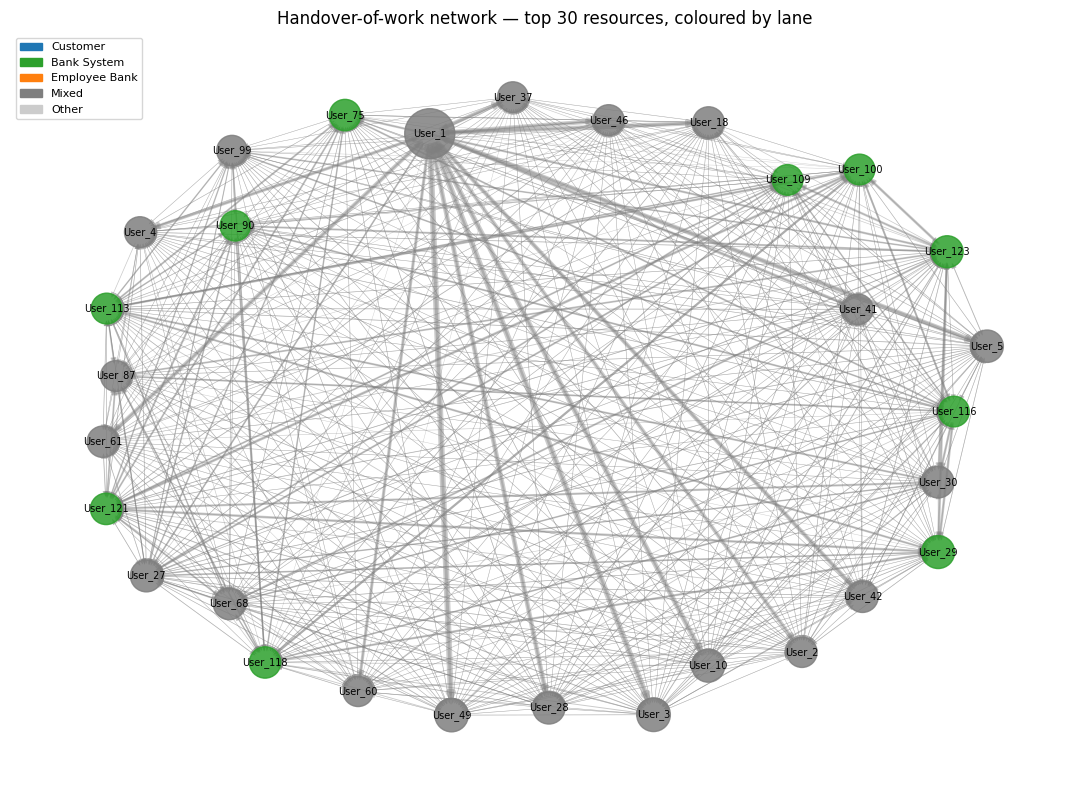

In [7]:
sna = pm4py.discover_handover_of_work_network(df)
print(f"Handover network: {len(sna.connections)} edges, directed={sna.is_directed}")

# Build a NetworkX graph filtered to top resources for readability
G = nx.DiGraph()
for (a, b), w in sna.connections.items():
    if a == b:
        continue
    G.add_edge(a, b, weight=w)

# Restrict to top-30 resources by event count for a readable plot
keep = set(res_counts.head(30).index)
G_top = G.subgraph(keep).copy()
print(f"Plot subgraph: {G_top.number_of_nodes()} nodes, {G_top.number_of_edges()} edges")

# Node colour = lane
lane_palette = {"Customer": "#1f77b4", "Bank System": "#2ca02c",
                "Employee Bank": "#ff7f0e", "Mixed": "#7f7f7f", "Other": "#cccccc"}
node_colors = [lane_palette.get(lane_mapping.loc[n, "assigned_lane"], "#cccccc")
               for n in G_top.nodes()]
node_sizes  = [200 + 4 * res_counts.get(n, 0)**0.5 for n in G_top.nodes()]
edge_weights = np.array([G_top[u][v]["weight"] for u, v in G_top.edges()])
edge_widths  = 0.3 + 4 * (edge_weights / edge_weights.max() if edge_weights.size else 0)

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G_top, seed=42, k=0.6)
nx.draw_networkx_nodes(G_top, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.85)
nx.draw_networkx_edges(G_top, pos, width=edge_widths, alpha=0.4, ax=ax,
                       edge_color="grey", arrows=True, arrowsize=8)
nx.draw_networkx_labels(G_top, pos, font_size=7, ax=ax)
# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in lane_palette.items()]
ax.legend(handles=handles, loc="upper left", fontsize=8, frameon=True)
ax.set_title("Handover-of-work network — top 30 resources, coloured by lane")
ax.axis("off")
plt.tight_layout()
plt.savefig("../results/figures/handover_network.pdf")
plt.savefig("../results/figures/handover_network.png", dpi=150)
plt.show()


## 7. Organisational roles (clusterer-validated lanes)

pm4py discover_organizational_roles clusters resources by activity similarity (an independent check on the lane mapping).

In [8]:
roles = pm4py.discover_organizational_roles(df)
print(f"Discovered {len(roles)} organisational roles")

role_rows = []
for i, role in enumerate(roles):
    # Majority lane of this role's activities
    lane_votes = pd.Series([LANE_FOR_ACTIVITY.get(a, "Other") for a in role.activities]).value_counts()
    role_rows.append({
        "role_id":      i,
        "n_activities": len(role.activities),
        "n_resources":  len(role.originator_importance),
        "majority_lane": lane_votes.idxmax(),
        "majority_share": round(lane_votes.iloc[0] / lane_votes.sum(), 2),
        "top_activities": ", ".join(role.activities[:4]),
        "top_resources":  ", ".join(list(role.originator_importance.keys())[:5]),
    })

roles_df = pd.DataFrame(role_rows)
roles_df.to_csv("../results/organizational_roles.csv", index=False)
roles_df


Discovered 14 organisational roles


,role_id,n_activities,n_resources,majority_lane,majority_share,top_activities,top_resources
0,0,6,125,Employee Bank,0.67,"A_Accepted, A_Complete, O_Create Offer, O_Created","User_10, User_100, User_101, User_102, User_103"
1,1,3,123,Bank System,0.67,"A_Cancelled, A_Concept, A_Create Application","User_1, User_10, User_102, User_103, User_104"
2,2,2,127,Bank System,1.00,"A_Validating, O_Returned","User_10, User_100, User_101, User_102, User_103"
3,3,2,99,Bank System,1.00,"A_Denied, O_Refused","User_10, User_100, User_101, User_102, User_106"
4,4,2,40,Bank System,1.00,"A_Pending, O_Accepted","User_100, User_102, User_106, User_107, User_109"
5,5,1,132,Bank System,1.00,O_Cancelled,"User_1, User_10, User_100, User_102, User_103"
6,6,1,105,Employee Bank,1.00,W_Call incomplete files,"User_10, User_100, User_101, User_102, User_105"
7,7,1,104,Employee Bank,1.00,O_Sent (online only),"User_10, User_100, User_101, User_102, User_103"
8,8,1,101,Bank System,1.00,A_Incomplete,"User_10, User_100, User_101, User_102, User_105"
9,9,1,91,Employee Bank,1.00,W_Validate application,"User_10, User_100, User_101, User_102, User_105"


## 8. BPMN claim verification: AND-splits, event-gateways, message events

The Celonis reference (Povalyaeva et al. 2017) proposes three constructs absent from the pm4py auto-export:

- an AND-split after A_Accepted (bank-system A_Complete parallel to the offer flow O_Create Offer -> O_Created -> O_Sent)
- an event-based gateway after O_Sent (mail and online) choosing between O_Returned and A_Incomplete / W_Call incomplete files
- message events at customer boundaries (A_Create Application, A_Submitted, O_Sent, O_Returned)

Verify each against the filtered log so every enrichment is empirically anchored, not borrowed.

### 8.1 Concurrency relation: does the Celonis AND-split appear empirically?

Using van der Aalst's α-relations on the directly-follows graph, label each pair: sequential (A->B only), concurrent ∥ (both A->B and B->A with non-negligible frequency), else unrelated. Focus on the pairs Celonis claims parallel.

In [9]:
from collections import Counter

# Build the directly-follows graph from the filtered log
dfg = Counter()
for _, group in df.sort_values(TS_COL).groupby(CASE_COL):
    acts = group[ACT_COL].tolist()
    for a, b in zip(acts, acts[1:]):
        if a != b:
            dfg[(a, b)] += 1

def relation(a, b, min_share=0.10):
    """Return (relation, ab_count, ba_count, symmetry).

    symmetry = min(ab, ba) / max(ab, ba); rejected as 'concurrent' if < min_share."""
    ab = dfg.get((a, b), 0)
    ba = dfg.get((b, a), 0)
    if ab == 0 and ba == 0:
        return ("unrelated", 0, 0, 0.0)
    sym = min(ab, ba) / max(ab, ba) if max(ab, ba) > 0 else 0
    if sym >= min_share:
        return ("concurrent (∥)", ab, ba, sym)
    return ("sequential", ab, ba, sym)

# Celonis-claimed concurrent pairs
celonis_concurrent_pairs = [
    ("A_Complete", "O_Create Offer"),
    ("A_Complete", "O_Created"),
    ("A_Complete", "O_Sent (mail and online)"),
    ("A_Complete", "W_Validate application"),
    ("A_Complete", "W_Call after offers"),
    ("W_Call after offers", "O_Returned"),
]

rows = []
for a, b in celonis_concurrent_pairs:
    rel, ab, ba, sym = relation(a, b)
    rows.append({
        "activity_a": a,
        "activity_b": b,
        "a→b count":  ab,
        "b→a count":  ba,
        "symmetry":   round(sym, 3),
        "relation":   rel,
    })

concurrency_df = pd.DataFrame(rows)
concurrency_df.to_csv("../results/bpmn_claim_concurrency.csv", index=False)
concurrency_df.to_latex(
    "../results/bpmn_claim_concurrency.tex",
    index=False,
    float_format="%.3f",
    caption="Concurrency verification: pairs the Celonis BPMN puts behind an AND-split. "
            "`symmetry` = $\\min(\\text{a→b}, \\text{b→a}) / \\max(\\ldots)$; "
            "the pair is labelled \\emph{concurrent} iff $\\text{symmetry} \\geq 0.10$.",
    label="tab:bpmn_concurrency",
)
concurrency_df


,activity_a,activity_b,a→b count,b→a count,symmetry,relation
0,A_Complete,O_Create Offer,4114,0,0.000,sequential
1,A_Complete,O_Created,0,0,0.000,unrelated
2,A_Complete,O_Sent (mail and online),41,12158,0.003,sequential
3,A_Complete,W_Validate application,0,0,0.000,unrelated
4,A_Complete,W_Call after offers,198,0,0.000,sequential
5,W_Call after offers,O_Returned,0,0,0.000,unrelated


### 8.2 Branching ratios after O_Sent (mail and online)

The claimed event-based gateway waits for O_Returned (signed offer) or A_Incomplete / W_Call incomplete files (documents missing). Justified only if both downstream branches occur with non-negligible share.

In [10]:
df_sorted = df.sort_values([CASE_COL, TS_COL]).copy()
df_sorted["next_act"] = df_sorted.groupby(CASE_COL)[ACT_COL].shift(-1)

after_osent = df_sorted.loc[df_sorted[ACT_COL] == "O_Sent (mail and online)", "next_act"]
total = after_osent.notna().sum()

branching = after_osent.value_counts().head(10).to_frame("count")
branching["share_percent"] = (branching["count"] / total * 100).round(1)

# Group the branches into Celonis branches
POSITIVE_BRANCH = {"O_Returned"}
NEGATIVE_BRANCH = {"A_Incomplete", "W_Call incomplete files"}
def classify(act):
    if act in POSITIVE_BRANCH: return "positive (O_Returned)"
    if act in NEGATIVE_BRANCH: return "negative (incomplete)"
    return "other"
branching["celonis_branch"] = branching.index.map(classify)
branching.to_csv("../results/bpmn_claim_event_gateway.csv")
branching.to_latex(
    "../results/bpmn_claim_event_gateway.tex",
    float_format="%.1f",
    caption="Event-based gateway verification: distribution of activities that immediately "
            "follow \\texttt{O\\_Sent (mail and online)} in the filtered log.",
    label="tab:bpmn_event_gateway",
)

pos_share = branching.loc[branching["celonis_branch"] == "positive (O_Returned)", "share_percent"].sum()
neg_share = branching.loc[branching["celonis_branch"] == "negative (incomplete)", "share_percent"].sum()
print(f"Total events after O_Sent (mail and online): {total:,}")
print(f"  positive branch (O_Returned):       {pos_share:.1f} %")
print(f"  negative branch (A_Incomplete/...): {neg_share:.1f} %")
print(f"  other:                              {100 - pos_share - neg_share:.1f} %")
branching


Total events after O_Sent (mail and online): 39,518
  positive branch (O_Returned):       0.6 %
  negative branch (A_Incomplete/...): 0.0 %
  other:                              99.4 %


,count,share_percent,celonis_branch
next_act,,,
W_Complete application,18612,47.1,other
A_Complete,12158,30.8,other
A_Validating,3215,8.1,other
O_Sent (mail and online),3109,7.9,other
A_Cancelled,1038,2.6,other
O_Create Offer,672,1.7,other
O_Cancelled,385,1.0,other
O_Returned,251,0.6,positive (O_Returned)
W_Validate application,23,0.1,other


### 8.3 Time-gap evidence for message events

A message event marks waiting for an external actor (the customer): the gap to its predecessor is hours or days, not seconds. Compare candidate transitions (e.g. O_Sent -> O_Returned) against intra-bank ones (e.g. A_Concept -> A_Accepted).

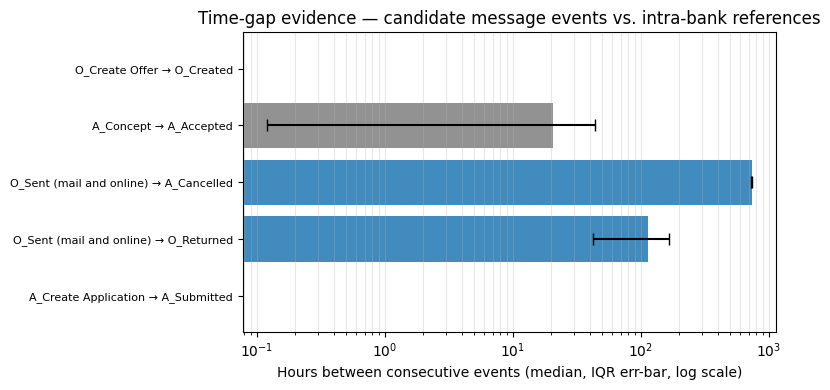

,transition,kind,n,median_h,p25_h,p75_h,mean_h
0,A_Create Application → A_Submitted,candidate,20338,0.00,0.00,0.00,0.00
1,O_Sent (mail and online) → O_Returned,candidate,251,113.64,42.03,165.00,123.87
2,O_Sent (mail and online) → A_Cancelled,candidate,1038,736.21,730.94,740.58,662.93
3,A_Concept → A_Accepted,reference,31353,20.71,0.12,43.87,34.09
4,O_Create Offer → O_Created,reference,42802,0.00,0.00,0.00,0.00


In [11]:
df_sorted["next_ts"] = df_sorted.groupby(CASE_COL)[TS_COL].shift(-1)
df_sorted["delta_h"] = (df_sorted["next_ts"] - df_sorted[TS_COL]).dt.total_seconds() / 3600

# Candidate message-event transitions (customer-driven) vs. reference intra-bank transitions
TRANSITIONS = {
    # Candidate message-event boundaries
    "A_Create Application → A_Submitted":           ("A_Create Application", "A_Submitted",          "candidate"),
    "O_Sent (mail and online) → O_Returned":        ("O_Sent (mail and online)", "O_Returned",       "candidate"),
    "O_Sent (mail and online) → A_Cancelled":       ("O_Sent (mail and online)", "A_Cancelled",      "candidate"),
    # Reference: should be fast (intra-bank, automatic or scheduled)
    "A_Concept → A_Accepted":                        ("A_Concept", "A_Accepted",                      "reference"),
    "A_Validating → A_Pending":                      ("A_Validating", "A_Pending",                    "reference"),
    "O_Create Offer → O_Created":                    ("O_Create Offer", "O_Created",                  "reference"),
}

rows = []
for label, (a, b, kind) in TRANSITIONS.items():
    deltas = df_sorted.loc[(df_sorted[ACT_COL] == a) & (df_sorted["next_act"] == b), "delta_h"]
    deltas = deltas.dropna()
    if deltas.empty:
        continue
    rows.append({
        "transition": label,
        "kind":       kind,
        "n":          len(deltas),
        "median_h":   round(deltas.median(), 2),
        "p25_h":      round(deltas.quantile(0.25), 2),
        "p75_h":      round(deltas.quantile(0.75), 2),
        "mean_h":     round(deltas.mean(), 2),
    })

gap_df = pd.DataFrame(rows)
gap_df.to_csv("../results/bpmn_claim_message_events.csv", index=False)
gap_df.to_latex(
    "../results/bpmn_claim_message_events.tex",
    index=False,
    float_format="%.2f",
    caption="Time-gap evidence for message events: median, IQR and mean hours between "
            "consecutive activities. Candidate message-event boundaries should show "
            "markedly larger gaps than intra-bank references.",
    label="tab:bpmn_message_events",
)

# Visualise as a horizontal box-plot-ish strip
fig, ax = plt.subplots(figsize=(8, 4))
order = gap_df.sort_values("kind")
xs = np.arange(len(order))
ax.barh(xs, order["median_h"], color=["#1f77b4" if k == "candidate" else "#7f7f7f" for k in order["kind"]],
        xerr=[order["median_h"] - order["p25_h"], order["p75_h"] - order["median_h"]],
        alpha=0.85, capsize=4)
ax.set_yticks(xs)
ax.set_yticklabels(order["transition"], fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Hours between consecutive events (median, IQR err-bar, log scale)")
ax.set_title("Time-gap evidence — candidate message events vs. intra-bank references")
ax.grid(axis="x", which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/bpmn_message_events.pdf")
plt.savefig("../results/figures/bpmn_message_events.png", dpi=150)
plt.show()

gap_df


## 9. Result + interpretation of H1, plus wrap-up

SNA result. Of 144 resources, only 37 (26 %) are cleanly lane-specialised (≥80 % of events in one Bank-System lane); 107 (74 %) are Mixed. The top-30 handover network is dense (807/870 directed edges, 92.8 %), and discover_organizational_roles finds 14 overlapping activity-based roles. User_1 is the sole executor of A_Submitted (the customer-self-service pseudo-user).

BPMN claim verification (§8). Each Celonis construct is checked against the log: §8.1 AND-split via directly-follows symmetry, §8.2 event-based gateway via downstream branch share, §8.3 message events via time-gap distribution.

H1 is rejected. Work is not team-bound: cases are handed off broadly and employees rotate across activity clusters. Simulation implication: one shared FIFO pool (≈144 users), not lane-bound teams; lanes stay for BPMN semantics only; User_1 gets a Customer-Channel annotation.

Artefacts:

§3.3 BPMN justification: results/lane_mapping.csv, results/lane_summary.csv/.tex, results/bpmn_claim_concurrency.csv/.tex, results/bpmn_claim_event_gateway.csv/.tex, results/bpmn_claim_message_events.csv/.tex, results/figures/bpmn_message_events.pdf.

§3.4 SNA: results/organizational_roles.csv, results/figures/handover_network.pdf, results/figures/resource_activity_heatmap.pdf.